# California Housing Price

### [Resource](https://drive.google.com/drive/folders/19YA_f36uGR86hTnZuX-Ech59s3AFzXXo)

### Contents:

1. Business Problem and Context
2. Data Understanding
3. Exploratory Data Analysis (EDA)
4. Data Prepocessing
5. Modelling
6. Model Evaluation
7. Result and Analysis
8. Conclusion and Recommendation

### 1. Business Problem and Context

#### Context

In the real estate indsutry, determining accurate house prices is an important challenge for companies that provide house-sellingg services. House prices are influenced by manya factors such as location, population, income level, housing conditions, and proximity to the ocean. Because of these factors, manual priceestimation can be difficult and may lead to inaccurate pricing decisions that affect sales performance and customer trust.

This proejct uses the California Housing dataset, which contains housing and demographic information collected from the 1990 California census. The dataset includes features such as logitude, latitude, hosuing median age, total rooms, popultaion, median income, and ocean proximity. These features can be anlayzed to identiy patterns related to house prices and support predictive modeling.

By applying Machine Learning techiques, this project aims to build a predictive model that can estimate median house values more accurately and efficiently. The model is expected to support companies in making more objective and data-driven pricing decisions.

#### Problem Statement

**How can Machine Learning help house-selling service companies determine accurate house prices based on housing and demographic features?**

House-sellign sevice companies often face challenges in determinin property prices because house values are influenced by many factors such as location, population, income level, and housing conditions. Manual pricing methods can result in inaccurate estimatins that may affect sales performance and customer trust. Therefore, a data-driven prediction model is needed to help companies estimate house prices more accuratley, efficiently, and objectively.

#### Goals

Based on the problem statement, the main goal of this project is to develop a Machine Learning model that can accurately predict median house values using housing adn demographic data.

The specific objectives are:

- To identify important features that influence house prices.
- to build and compare regression models for house price prediction.
- To evaluate model perfromance using regression metrics.
- To support more accurate and data-driven pricing decisions for house-selling service companies.

#### Analytic Approach

This project uses a supervised learing regression approach because the target variable (median house value) is numerical. The analytical process includes:

- Understanding and exploring the dataset
- Performing data preprocessing and feature preparation
- Training regression models
- Evaluating and comparing model perfromance

Several regression algorithms such as Linear Regression, Decision Tree Regressor, Random Forest Regressor, XGBoost Regressor, and Gradien Boositng Regressor can be used to identify the best-performing model for house price prediction.

#### Metric Evaluation

The regression models will be evaluated using:
- **MAE (Mean Absolute Error)** → measures the average absolute difference between the actual house prices and the predicted house prices generated by the model. This metric shows how far the predictions are from the real values on average without considering the direction of the error. A lower MAE value indicates that the model produces mor accurate prdictions and smaller prediction errors.
  
- **RMSE (Root Mean Squared Error)** → measures the square root of the avcerage squared differences between actual and predicted values. Since the errors are squared before averaging, RMSE gives a higher penalty to large precition errors. This metric is useful for identifying models that produce significant mistakes in prediction. Lower RMSE values indicate better model perfromance and more reliable predictions.

- **R² Score (Coefficient of Determination)** → measures how wel the independent variables ecplain the variation in the target variable (median house value). The value ranges from 0 to 1, whre values closer to 1 indicate that the model can explain most of the variability in house prices. A higher R² Score means the model has better predictive capability and fits the data more effectively.

The best model will best selected based on lower error values and a higher R² Score, indicating better prediction performance.


### 2. Data Understanding

The dataset used in this project is the **California Housing Dataset**, which contains housing and demographic information collected from the 1990 California census. The dataet is commontly used for regression and house price prediction tasks because it contains several important features related to housing condistion, income levels, population, and geographical location. The main objective of this project is to predict the **median house value** based on the available features.

Each row in the dataset represents one district in California, while each column represents a specific feature related to ousing and demographic characteristics in that district.

#### 2.1 Import Library

The first step is importing the required libraries for data analysis and visualization

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#### 2.2 Load Dataset

The dataset is loaded using Pandas to begin the analysis process.

In [3]:
df = pd.read_csv("data_california_house.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-119.79,36.73,52.0,112.0,28.0,193.0,40.0,1.9750,INLAND,47500.0
1,-122.21,37.77,43.0,1017.0,328.0,836.0,277.0,2.2604,NEAR BAY,100000.0
2,-118.04,33.87,17.0,2358.0,396.0,1387.0,364.0,6.2990,<1H OCEAN,285800.0
3,-118.28,34.06,17.0,2518.0,1196.0,3051.0,1000.0,1.7199,<1H OCEAN,175000.0
4,-119.81,36.73,50.0,772.0,194.0,606.0,167.0,2.2206,INLAND,59200.0


#### 2.3 Dataset Shape

Checking the number of rows and columns in the dataset

In [4]:
df.shape

(14448, 10)

This step helps identify the dataset size and overall structure.

#### 2.4 Dataset Information

Checking the datset information including:

- column names
- data types
- number of non-null values

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14448 entries, 0 to 14447
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           14448 non-null  float64
 1   latitude            14448 non-null  float64
 2   housing_median_age  14448 non-null  float64
 3   total_rooms         14448 non-null  float64
 4   total_bedrooms      14311 non-null  float64
 5   population          14448 non-null  float64
 6   households          14448 non-null  float64
 7   median_income       14448 non-null  float64
 8   ocean_proximity     14448 non-null  object 
 9   median_house_value  14448 non-null  float64
dtypes: float64(9), object(1)
memory usage: 1.1+ MB


#### 2.5 Statistical Summary
Displaying sttistical information for numerical features.

In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,14448.000000,14448.000000,14448.000000,14448.000000,14311.000000,14448.000000,14448.000000,14448.000000,14448.000000
mean,-119.566647,35.630093,28.618702,2640.132683,538.260709,1425.157323,499.508929,3.866667,206824.624516
std,2.006587,2.140121,12.596694,2191.612441,423.577544,1149.580157,383.098390,1.891158,115365.476182
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1451.000000,295.000000,784.000000,279.000000,2.570600,119600.000000
50%,-118.490000,34.260000,29.000000,2125.000000,435.000000,1165.000000,410.000000,3.539100,180000.000000
75%,-118.000000,37.710000,37.000000,3148.000000,647.000000,1724.000000,604.000000,4.736100,263900.000000
max,-114.310000,41.950000,52.000000,32627.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


#### 2.6 Missing Value Analysis

Checking missing values in each column.

In [7]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        137
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64

### 3. Exploratory Data Analysis(EDA)

#### 3.1 Dataset Features

|**Feature** |**Data Type**|**Description**|
|---|---|---|
| longitude | float64 | Geographical longitude coordinate |
| latitude | float64 | Geographical latitude coordinate |
| housing_median_age | float64 | Median age of houses |
| total_rooms | float64 | Total number of rooms |
| total_bedrooms | float64 | Total number of bedrooms |
| population | float64 | Total population |
| households | float64 | Total number of households |
| median_income | float64 | Median income of residents |
| ocean_proximity | object | Distance category from ocean |
| median_house_value | float64 | Median house value (target variable) |

<br>

The target variable in this project is:

- **median_house_value**

Since the target variable contains continuous numerical values, this project is categorized as a **regression problem**.


#### 3.2 Feature Distribution Analysis

Histograms visualization is used to analyze the distribution of numerical variables in the dataset.

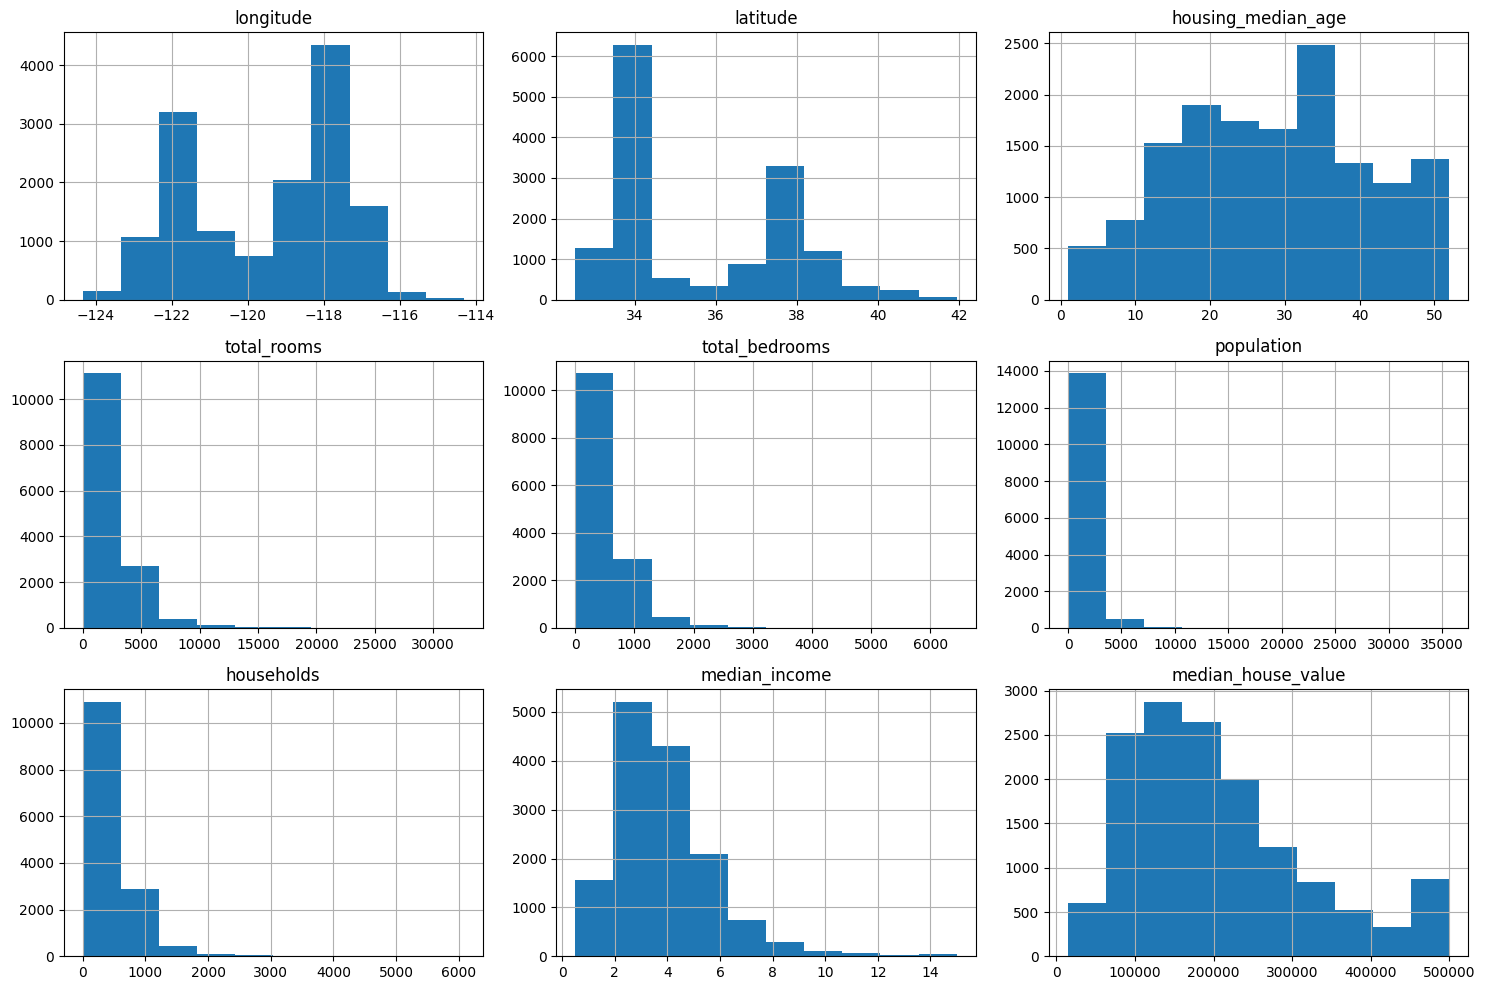

In [8]:
df.hist(figsize=(15,10))

plt.tight_layout()
plt.show()

#### Insight

The histogram analysis shows that several numerical features such as **total_rooms**, **total_bedrooms**, **population**, and **households** are positively skewed. This inicating that most districts contain relatively smaller values while only a few districts have extremely large values. The distribution of **median_hous_valuer** shows that most house prices are concentrated beluw 300,000 with some values reaching the upper limit around 500,000.

In addition, several variables appear to contain potential outliers with extremely high values, which may affect model performance during training. The differences in feature scales also indicate that feature scaling may be necessary during the preprocessing stage to improve model performance and ensure more balanced learning across features.

#### 3.3 Correlation Analysis

Correlation analysis is performed to identify relationships between numerical variables.

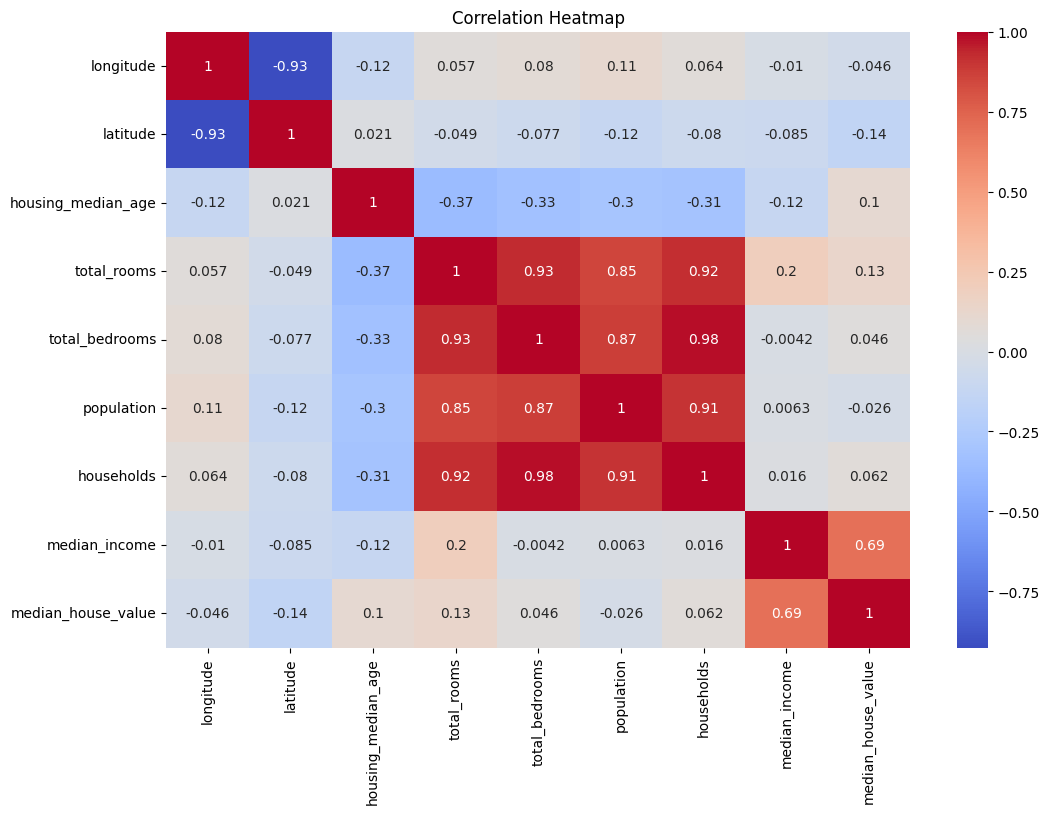

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The correlation analysis shows that **median_income** has the strongest positive correlation with **median_house_value** compared to other features, with a correlation value of approcimately 0.69. This indicates that districts with higher income levels generally tend to have higher house prices, making **median_income** one og the most improtant features for house price prediction.

Several features such as **total_rooms, **total_bedrooms**, **population**, adn **households** aslo show strong correlations with ecah other, indicating potentital multicollinearity among variables. In addition, geographical features such as **logitude** and **latitude** show negative correlations with house prices, suggesting that location also plays an important role in determining property values.

#### 3.4 Relationship Between Features and House Prices

Scatterplots are used to analyze relationships between important variables and house price

<function matplotlib.pyplot.show(close=None, block=None)>

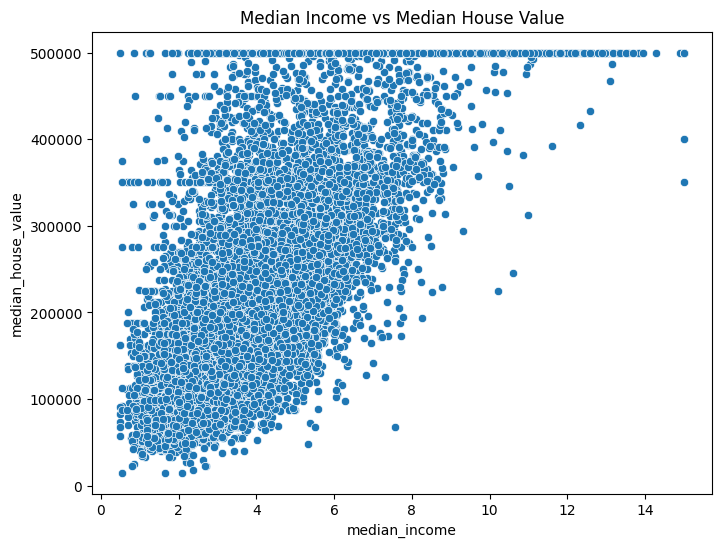

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['median_income'],
    y=df['median_house_value']
)

plt.title("Median Income vs Median House Value")
plt.show

The scatterplot shows a clear positive realtionship berween **median_income** and **median_house_value**, where house prices generally increase as the median income of residents increases. Districts with higher income lebels tend to have significantly higher property values compared to districts with lower income levels.

The visualization also indcates that **median_income** is one of the most influential features in predicting house prices. In addition, several housse price appear capped around 500,000 suggesting a possible upper limit in the dataset. From a business perspective, income level can become an important indicator for house-selling service companies in estimating property prices more accurately.
    

#### 3.5 Ocean Proximity vs Median House Value

Boxplot visualtization is used to analyze how house prices vary based on proximity to the ocean.

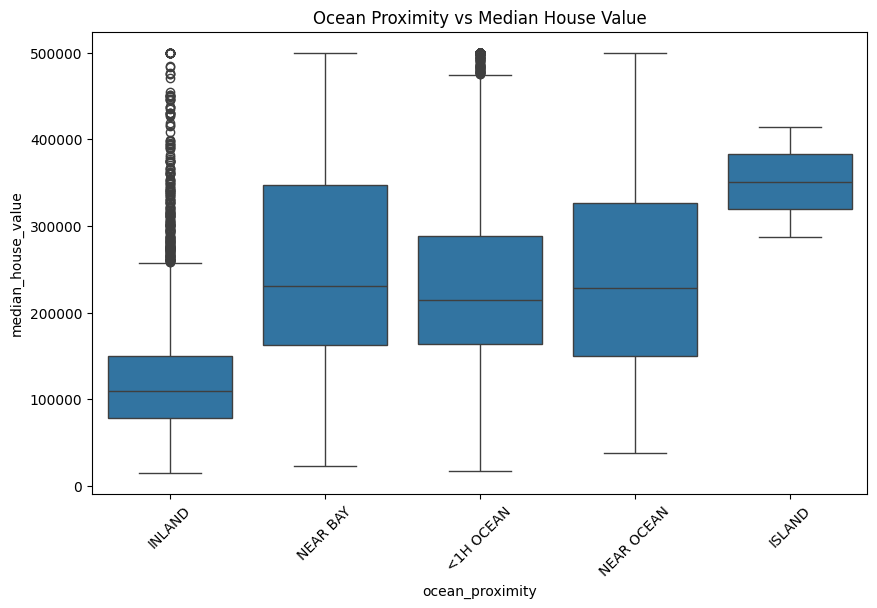

In [11]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['ocean_proximity'],
    y=df['median_house_value']
)

plt.xticks(rotation=45)

plt.title("Ocean Proximity vs Median House Value")

plt.show()

The boxplot analysis shows that house prices vary significantly based on **ocean_proximity.** Districts categorized as **ISLAND**, **NEAR BAY**, and **NEAR OCEAN*8 generally have higher median house values compared to **INLAND** districts, indictaing that houses located closer to the ocean tend to have higher property values.

The **INLAND** category has the lowest median house prices, while the **ISLAND** category shows the highest median values with a relatively narrower distribution range. In addition, several outliers are visible in the **INLAND** category, indicating that some inland districts still contain high-value properties. These findings suggest that proximity to the ocean is an important factor influencing house prices and should be considered in the prediction model.

#### 3.6 Geographical Distribution of House Prices

Geographical visualization is used to analyze the distribution of house prices based on district location.

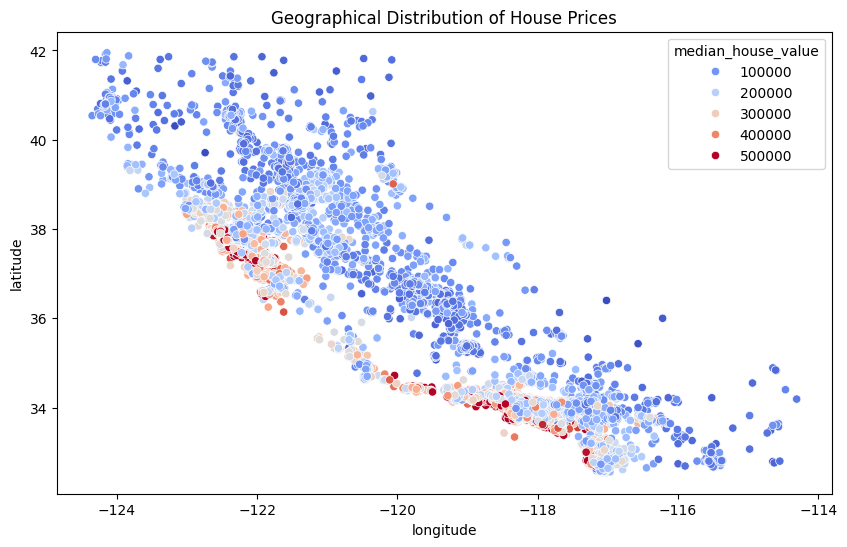

In [12]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['longitude'],
    y=df['latitude'],
    hue=df['median_house_value'],
    palette='coolwarm'
)

plt.title("Geographical Distribution of House Prices")

plt.show()

The geographical visualtization shows that house prices are distributed differently across various locations in California. Areas represented by warmer colors **(higher house prices)** are mostly concentrated near coastal regions, while inland areas are generally associated with lower house prices.

The visualization also indicates that geographical features such as **longitude** and **latitude** have a significant influence on property values. Districts located closer to coastal and urban areas tend to have higher median house values compared to districts located farhter indland. These findings suggest that location is an important factor in predicting house prices and should be included in the Machine Learning model.

#### 3.7 Key Findings from EDA

Based on the exploratory data analysis, several imprtan findings were identified from the California Housing dataset. The analysis shows that **median_income** is the most influential feature affecting house prices, where districts with higher income levels generally tend to have higher median house values. This relationship is clearly visible in both the correlation analysis and scatterplot visualization.

The analysis also indicates that gegraphical factors such as **longitude**, **latitude**, and **ocean_proximity** significantly influence property values. Houses located near coastal areas, bays, or islands generally have higher prices compared to inland districts. In addition, several numerical features such as **total_rooms**, **population**, and **households** are positively skewed and contain potential outliers.

Futhermore, somve variables show strong correlations with each other, indicating possible multicollinerarity among features. These findings suggest that preprocessing techniques susch as handling missing values, encoding categorical variables, and feature scaling may be necessary before builidng the Machine Learning models.

### 4. Data Preprocessing

Data preprocessing is an important step before building Machine Learning models. This process aims to clean and transform the dataset into a suitable format for regression modeling. Several preprocessing techinques are applied, including handling missing values, encoding categorical variables, splitting the dataset, and feature scaling.

#### 4.1 Handling Missing Values

Before building the Machine Learning mdoles, it is important to identify and handle missing values in the datset becaruse incomplete data may affect model performance and prediction accuracy.

A heatmap visualization is used to identify the distribution of missing values in the dataset

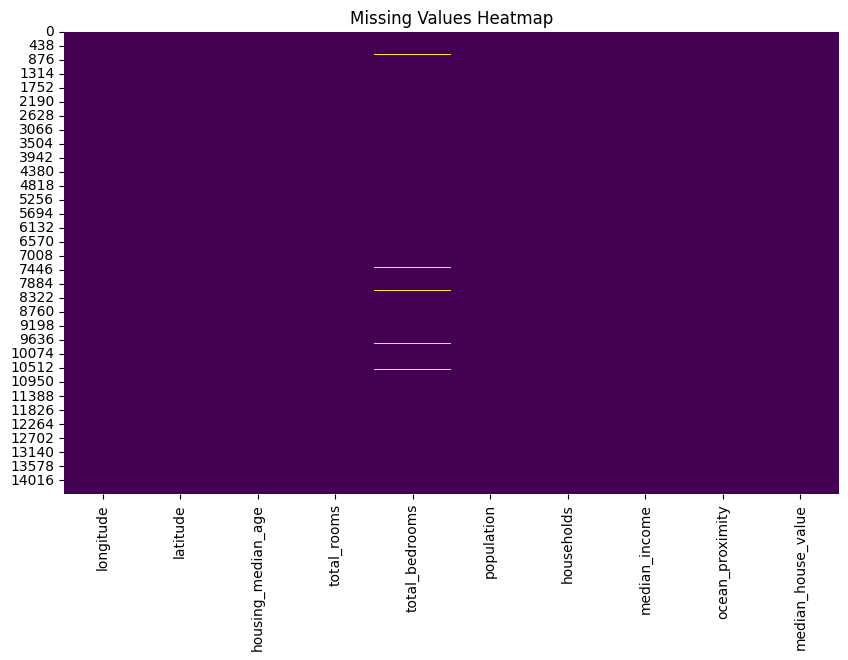

In [13]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")

plt.show()

The visualization shows that missing values are only present in the **total_bedrooms** feature, while the other features do not contain null values.

To handle the missing values, median imputaiton is applied because the median is more robust to outliers and suitable for skewed numerical distributions.

In [14]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(
    df['total_bedrooms'].median()
)

Check the dataset again after imputation:

In [15]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
median_house_value    0
dtype: int64

The missing value analysis confirms that only the **total_bedrooms** feature contains null values. After applying median imputation, all mising values were successfully hadled, ensuring taht the dataset is complete and ready for the next preprocessing stage.
    

#### 4.2 Feature and Target Separation

The target variable used in this project is **median_house_value**, while the remaining columns are used as input features for prediction

In [16]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

This step separates the independent variables (features) from the depndent variable (target) before model training.

#### 4.3 Encoding Categorical Features

The **ocean_proximity** feature contains categorical values that cannot be rpcessed directly by mos Machine Learning algorithms. Therefore, One-Hot Encoding is applied to convert categorical data into numerical format.

In [17]:
X = pd.get_dummies(
    X,
    columns=['ocean_proximity'],
    drop_first=True
)

After encoding, the categorical feature is transformed into mulitple binary columns, allowing the regression models to process the dataset correctly.

#### 4.4 Train-Test Split
The dataset is divided into training and testing sets. The training data is used to train the models, while the testing data is used to evaluate model performance.


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

The dataset is split using an 80:20 ration, where 80% of the data is used for training and 20% is used for testing

#### 4.5 Feature Scaling

Feature scaling is perfromed to standardize numerical feature values and reduce scale differences between variables. StandardScaler is used to normalize the data.

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Feature scaling helps improve model performance, especially for alforithms that are sensitive to differences in feature magnitude.

#### 4.6 Preprocessing Result

After completing the preprocessing stage:

- Missing values have been handled successfully.
- Categorical variables have been encoded into numerical format.
- Features and target variables have been separated.
- The dataset has been split into training and testing sets.
- Numerical features have been standardized using feature scaling.

### 5. Modelling
In this stage, several regression algortihms are used to build and compare house price prediciton models. The ovjective is to identify the best=performing model for predicting **median_house_value** based on the available housing and demographic features.

The models used in this project are:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor

#### 5.1 Import Machine Learning Models
The required regression algorithms and evaluation metrics are imported before model training.

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

#### 5.2 Model Initialization
Initialize all regression models used in this project

In [21]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        random_state=42
    )
}

#### 5.3 Model Training
Each model is trained using the training dataset.

In [22]:
for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    print(f"{name} trained successfully")

Linear Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully
Gradient Boosting trained successfully
XGBoost trained successfully


All regression models were successfully trained using the preprocessed training dataset.

#### 5.4 Model Prediction

After training, predictions are generated using the testing dataset.

In [23]:
predictions = {}

for name, model in models.items():

    y_pred = model.predict(X_test_scaled)

    predictions[name] = y_pred

Each regression model produces predicted house prices based on the testing data, which wil bbe evaluated in the next stage

#### 5.5 Modelling Summary
The modelling stage succesfully builds multiple regression models for house price prediction. Using several algorithms allows performance comparison to identify which model provides the most accurate and reliable predictions for the California Housing dataset.

The trained models will be evaluated using regression metrics such as MAE, RMSE, and R² Score in the next stage.

### 6. Model Evaluation

Model evaluation is performed to measure the performance of each regression algorithm in predicting house prices. The evaluation process uses several regression metrics, including MAE, RMSE, and R² Score. 

- **MAE (Mean Absolute Error)** measures the average absolute difference between actual and predicted values.
- **RMSE (Root Mean Squared Error)** measures prediction error with higher penalties for large errors.
- **R² Score** measures how well the model explains the target variable.

The best model is determined based on:
- Lower MAE and RMSE values
- Higher R² Score

#### 6.1 Model Evaluation Process
The following code evalutes all trained models using the testing dataset.

In [24]:
results = []

for name, model in models.items():

    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    results.append([
        name,
        mae,
        rmse,
        r2
    ])

#### 6.2 Evaluation Result Table
Convert the evaluation results into a DataFrame for easier comparison.

In [25]:
evaluation_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'MAE',
        'RMSE',
        'R2 Score'
    ]
)

evaluation_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,49860.663848,69638.878415,0.636764
1,Decision Tree,46369.870588,73291.882678,0.597657
2,Random Forest,32614.916893,49946.093527,0.813152
3,Gradient Boosting,38026.921995,54434.986179,0.778057
4,XGBoost,32615.299325,48724.609615,0.822180


#### 6.3 Evaluaton Visualization
Visualization is used to compare model performance more clearly

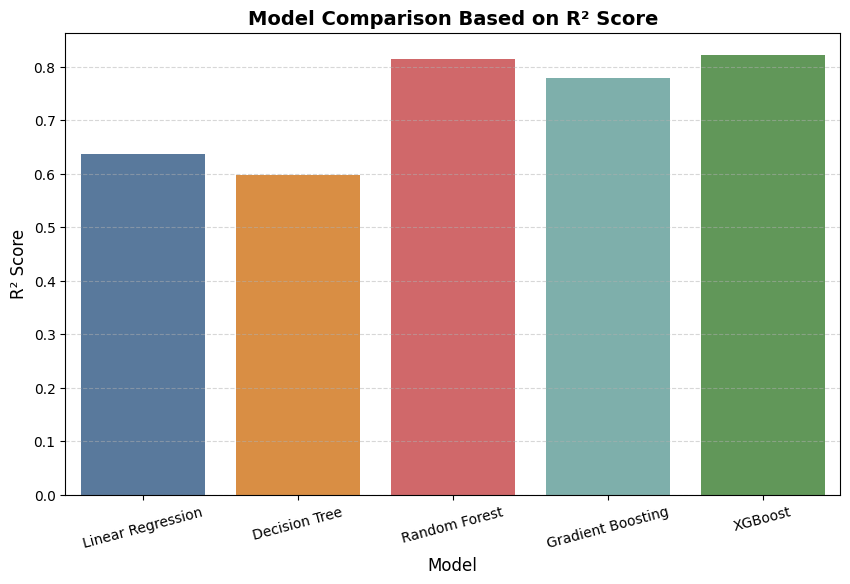

In [26]:
plt.figure(figsize=(10,6))

colors = [
    '#4E79A7',
    '#F28E2B',
    '#E15759',
    '#76B7B2',
    '#59A14F'
]

sns.barplot(
    data=evaluation_df,
    x='Model',
    y='R2 Score',
    palette=colors
)

plt.title(
    "Model Comparison Based on R² Score",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Model", fontsize=12)
plt.ylabel("R² Score", fontsize=12)

plt.xticks(rotation=15)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#### 6.4 Evaluation Insights
The evaluation results show clear differences in performance among the regression models. Linear Regression and Decision Tree produce relatively higher MAE and RMSE values, indicating larger prediction errors compared to the other models. Their R² Scores are also lower, suggesting that these models are less effective in explaining the variability of house prices. On the other hand, ensemble-based models such as Random Froest, Gradient Boosting, and XGBoost demonstrate significantly better performance with lower prediction errors and higher R² Scores.

Among all evaluated models, XGBoost achieves the best overall performance with the highest R² Score of approximately 0.82 and one of the lowest RMSE values, indicating strong predictive capability and more accurate house price estimation. Random Forest also performs competitively with a very similar performance level, while Gradient Boosting achieves stabel results with slightly lower accuracy. These findings suggest that ensemble learning methods are more effective in capturing the complex relationships between 

#### 6.5 Best Model Selection

Based on the evaluation results, XGBoost is selected as the best-performing model because it achieves:
- The highest R² Score
- The lowest prediction errors
- Strong and stable predictive performance
  
Random Forest also demonstrates competitive performance and becomes another strong candidate for futrher optimization. Therfore, both XGBoost and Random Forest are selected for the hyperparameter tuning stage.

### 7. Hyperparameter Tuning

Hyperparameter tuning is performed to optimize the performance of the best-performing models identified during the evaluation stage. Based on the previous results, **XGBoost** and **Random Forest** are selected for further optimization because both models achieved the highest R² Scores and the lowest prediction errors.

The tuning process aims to imporve model accuracy by finding the optimal combination of hyperparmeters.

#### 7.1 Hyperparameter Tuning for Random Forest

RandomizedSearchCV is used to search for the best hyperparameter combinations for the Random Forest model.

#### Define Hyperparameter Grid

In [27]:
from sklearn.model_selection import RandomizedSearchCV

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

#### Perform Random Search

In [28]:
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_distributions=rf_params,
    n_iter=10,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


#### Best Random Forest Parameters

In [29]:
print(rf_random.best_params_)

{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}


#### 7.2 Hyperparameter Tuning for XGBoost

RandomizedSearchCV is also applied to optimize the XGBoost model.

#### Define Hyperparameter Grid

In [30]:
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

#### Perform Random Search

In [31]:
xgb_random = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42
    ),
    param_distributions=xgb_params,
    n_iter=10,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [32]:
xgb_random.best_params_

{'subsample': 1.0,
 'n_estimators': 200,
 'max_depth': 5,
 'learning_rate': 0.1,
 'colsample_bytree': 0.8}

#### Best XGBoost Parameters

#### 7.3 Tuned Model Evaluation

After tuning, the optimzed models are evaluated again using the testing dataset

In [33]:
rf_best = rf_random.best_estimator_
xgb_best = xgb_random.best_estimator_

rf_pred = rf_best.predict(X_test_scaled)
xgb_pred = xgb_best.predict(X_test_scaled)

#### Calculate Evaluation Metrics

In [34]:
tuned_results = pd.DataFrame({

    'Model': [
        'Random Forest Before Tuning',
        'Random Forest Tuned',
        'XGBoost Before Tuning',
        'XGBoost Tuned'
    ],

    'MAE': [
        mean_absolute_error(
            y_test,
            models['Random Forest'].predict(X_test_scaled)
        ),

        mean_absolute_error(
            y_test,
            rf_pred
        ),

        mean_absolute_error(
            y_test,
            models['XGBoost'].predict(X_test_scaled)
        ),

        mean_absolute_error(
            y_test,
            xgb_pred
        )
    ],

    'RMSE': [
        np.sqrt(
            mean_squared_error(
                y_test,
                models['Random Forest'].predict(X_test_scaled)
            )
        ),

        np.sqrt(
            mean_squared_error(
                y_test,
                rf_pred
            )
        ),

        np.sqrt(
            mean_squared_error(
                y_test,
                models['XGBoost'].predict(X_test_scaled)
            )
        ),

        np.sqrt(
            mean_squared_error(
                y_test,
                xgb_pred
            )
        )
    ],

    'R2 Score': [

        r2_score(
            y_test,
            models['Random Forest'].predict(X_test_scaled)
        ),

        r2_score(
            y_test,
            rf_pred
        ),

        r2_score(
            y_test,
            models['XGBoost'].predict(X_test_scaled)
        ),

        r2_score(
            y_test,
            xgb_pred
        )
    ]
})

tuned_results

,Model,MAE,RMSE,R2 Score
0,Random Forest Before Tuning,32614.916893,49946.093527,0.813152
1,Random Forest Tuned,32444.880243,49600.289787,0.815730
2,XGBoost Before Tuning,32615.299325,48724.609615,0.822180
3,XGBoost Tuned,32342.028755,48026.086242,0.827241


#### 7.4 Before vs After Tuning Comparison

#### Visualization

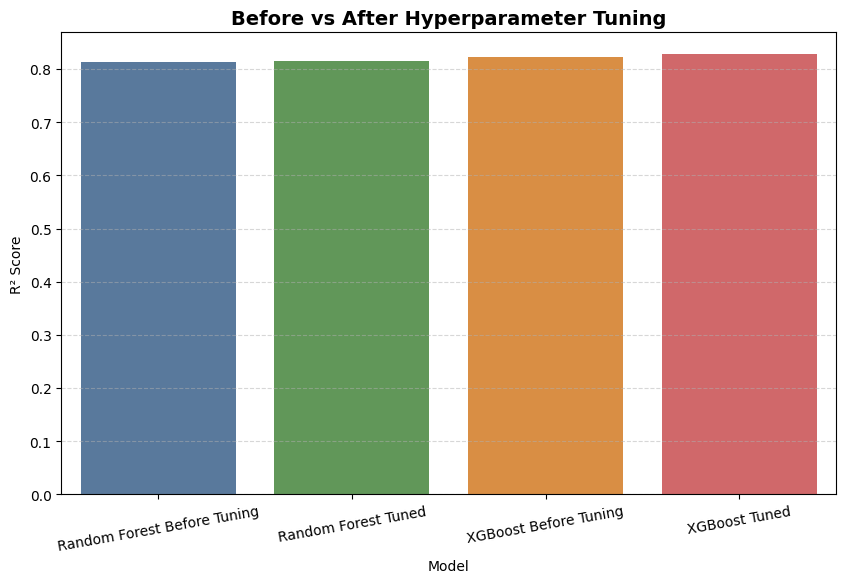

In [35]:
plt.figure(figsize=(10,6))

colors = [
    '#4E79A7',
    '#59A14F',
    '#F28E2B',
    '#E15759'
]

sns.barplot(
    data=tuned_results,
    x='Model',
    y='R2 Score',
    palette=colors
)

plt.title(
    "Before vs After Hyperparameter Tuning",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=10)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#### 7.5 Hyperparameter Tuning Insights

The hyperparameter tuning process improves the performance of both random Forest and XGBoost models. By optimizin parameters such as **n_estimators**, **max_depth**, and **learning_rate**, the models become more effective in capturing complex relationships within the datasets.

The comparison results show that hyperparameter tning provides slight performance improvements for both models. Although the improvements for both models. Although the improvements are not significantly large, the tuned models achieve slightly better R² Scores and lower prediction errors compared to the default models. This indicates that the default ensemble models already perform strongly on the California Housing dataset, while hyperparameter optimization helps further refine model performance and stability.

Among all evaluated models, the tuned XGBoost model remains the best-performing algorithm with the highest perdictive accuracy and the strongest overall performance. These findings suggest that ensemble-based approaches, especially boosting methods, are highly effective in predicting house prices because they can better capture complex relationships between housing, income, and geographical features.

### 8. Final Model Evaluation

#### 8.1 Actual vs Predicted Plot

The Actual vs Predicted plot is used to evaluate how close the predicted house price are to the actual house prices.

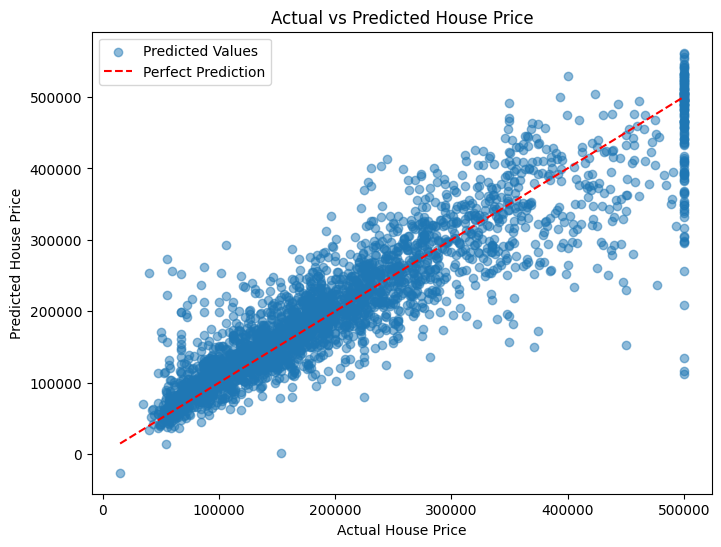

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5, label='Predicted Values')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
     label='Perfect Prediction'
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Price")

plt.legend()

plt.show()

The Actual vs Predicted plot shows that most prediction points are distributed relatively close to the diagonal reference line, indicating that the tuned XGBoost model was able to predict house prices reasonably well. The model demonstrates strong predictive performance for houses within the mid-price range, as many points closely follow the perfect prediction line. This suggests that the relationship between the housing features and target variable was successfully captured by the model.

However, the visualization also shows wider prediction dispersion for houses with very high prices, particularly near the upper price limit. This indicates that the model still experiences larger prediction errors for expensive or less common properties. In addition, several prediction outliers can be observed, where the predicted values differ significantly from the actual values. This may occur because certain external factors affecting house prices are not included in the dataset, such as house interior condition, nearby facilities, neighborhood quality, or real-time market trends.

Overall, the plot suggests that the tuned XGBoost model is sufficiently reliable for supporting house price estimation tasks and can assist property companies in making more objective and efficient pricing decisions.

#### 8.2 Residual Plot

Residual analysis is performed to evaluate the prediction errors produced by the model. Residual values represent the difference between the actual values and predicted values.

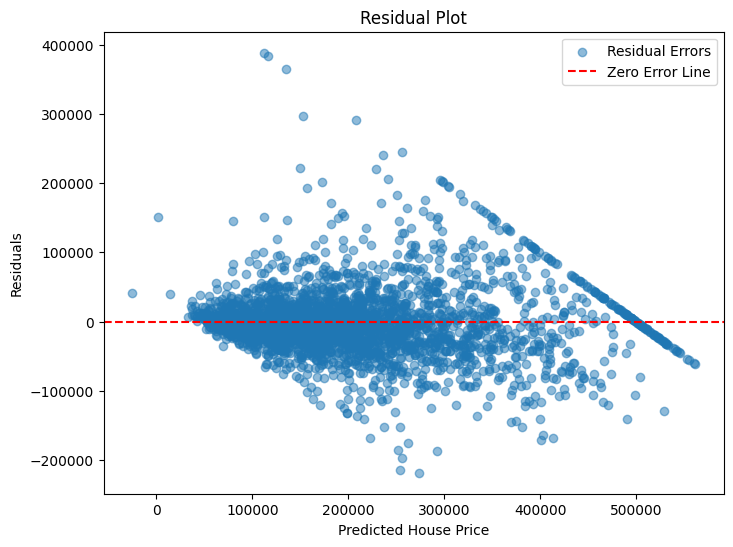

In [37]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.5, label='Residual Errors')

plt.axhline(y=0, color='r', linestyle='--', label='Zero Error Line')

plt.xlabel("Predicted House Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.legend()

plt.show()

The residual plot shows that most residual values are distributed around the zero-error line, indicating that the tuned XGBoost model generally produces balanced predictions without strong systematic overestimation or underestimation. The residual distribution appears relatively random for low to medium predicted house prices, suggesting that the model is able to capture the relationship between housing features and house prices reasonably well within these price ranges.

However, the spread of residuals becomes wider as predicted house prices increase, indicating that prediction errors tend to be larger for expensive houses. Several large positive and negative residuals are still visible, which suggests that some important real-world factors affecting house prices may not be fully represented in the dataset, such as property condition, renovation quality, neighborhood safety, nearby facilities, and current market trends. Overall, the residual analysis indicates that the tuned XGBoost model performs reasonably well for general house price estimation tasks, although prediction reliability decreases slightly for houses with extreme or uncommon price characteristics..

#### 8.3 Error Distribution Analysis

The distribution of residual errors helps evaluate whether prediction errors are concentrated near zero and whether the model tends to systematically overestimate or underestimate house prices.

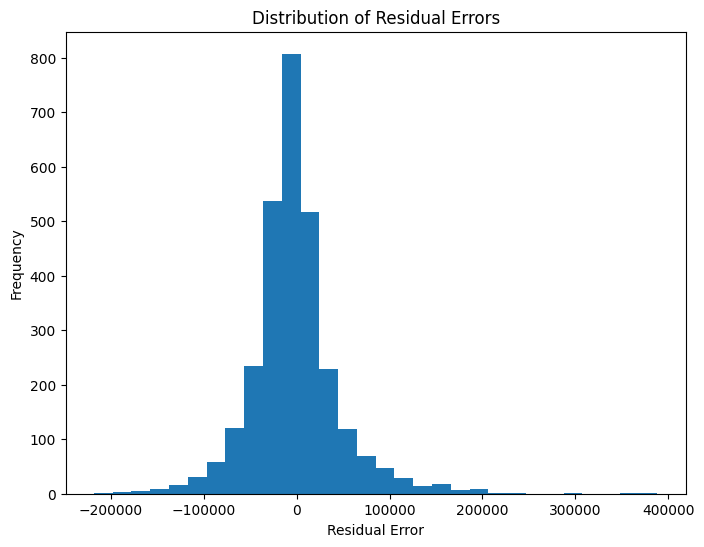

In [38]:
plt.figure(figsize=(8,6))

plt.hist(residuals, bins=30)

plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.title("Distribution of Residual Errors")

plt.show()

The distribution of residual errors is centered around zero, indicating that most prediction errors produced by the tuned XGBoost model are relatively small and balanced between overestimation and underestimation. The histogram also shows that the majority of residual values are concentrated near the center, suggesting that the model performs reasonably well for most house price predictions.

However, the distribution still contains several extreme residual values on both the positive and negative sides, indicating that larger prediction errors still occur for certain houses. This suggests that some real-world factors influencing house prices may not be fully captured by the dataset, such as property condition, renovation quality, neighborhood environment, nearby facilities, and changing market trends. Overall, the residual error distribution indicates that the model is sufficiently stable for general house price estimation tasks while still having limitations for properties with unusual characteristics or extreme prices.

#### 8.4 Feature Importance Analysis

Feature importance analysis was conducted to identify which variables contributed the most to house price prediction.

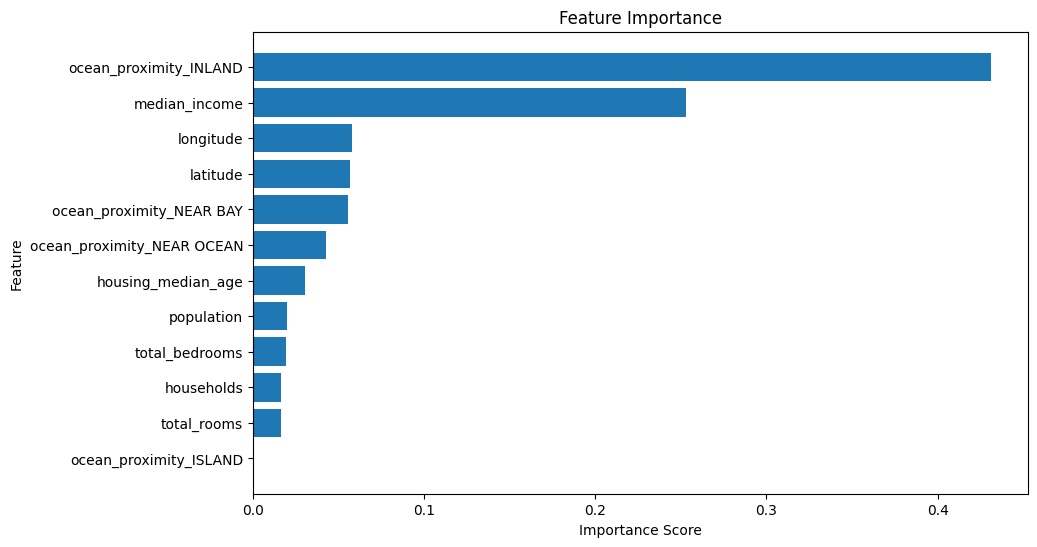

In [39]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_best.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

The feature importance analysis shows that **ocean_proximity_INLAND** is the most influential feature in predicting house prices, followed by **median_income**. This indicates that geographical location and regional economic conditions play major roles in determining housing prices in California. Houses located inland tend to have significantly different pricing patterns compared to houses located near coastal areas, while areas with higher median income generally have higher property values.

In addition, geographical coordinates such as **longitude** and **latitude*8 also contribute noticeably to the prediction model, reinforcing the importance of location in the housing market. Features related to housing characteristics, such as **housing_median_age**, **total_rooms**, **total_bedrooms**, and **households**, have relatively smaller contributions compared to economic and location-based variables. Overall, the results suggest that location and socioeconomic factors are more influential than physical housing attributes in predicting house prices within this dataset.

### 9. Conclusion and Recommendation 

#### 9.1 Conclusion

This project successfully developed several **Machine Learning regression models** to predict **median house prices** using the **California Housing dataset**. The project covered the complete machine learning workflow, including **data understanding, exploratory data analysis (EDA), data preprocessing, model development, hyperparameter tuning, evaluation, residual analysis, and feature importance analysis**.

The evaluation results showed that **ensemble-based models**, particularly **Random Forest** and **XGBoost**, outperformed simpler models such as **Linear Regression** and **Decision Tree**. After hyperparameter tuning, the **tuned XGBoost model** achieved the best overall performance with an **R² Score of approximately 0.827** and the **lowest RMSE value of around 48,026** among all evaluated models. This indicates that the model was able to explain around **82.7% of the variation in house prices** using the available housing features in the dataset.

In practical terms, the prediction error suggests that the estimated house prices may differ from the actual market prices by approximately **$48,000 on average**. Although the model is not perfectly accurate, the prediction results are still sufficiently reliable to support initial house price estimation and pricing decision-making processes in the real estate industry.

The **residual analysis** and **Actual vs Predicted visualization** also demonstrated that the tuned XGBoost model was able to produce reasonably accurate and balanced predictions for most houses. However, prediction errors became larger for houses with **extreme or uncommon price values**, indicating that several external real-world factors affecting house prices were not fully represented in the dataset.

Feature importance analysis revealed that **location-related and socioeconomic variables**, especially **`ocean_proximity_INLAND`**, **`median_income`**, **`longitude`**, and **`latitude`**, were the most influential features in predicting house prices. These findings indicate that **geographical location** and **regional economic conditions** play more significant roles in determining property prices compared to several physical housing characteristics.

For example, if the actual house price is around **$300,000**, the model prediction may still differ by tens of thousands of dollars depending on property characteristics and market conditions. Therefore, the model is more suitable as a **decision-support tool** rather than a fully automated pricing system.

Overall, the final **XGBoost model** can effectively support **property companies, real estate agents, and house-selling service providers** in estimating house prices more efficiently, consistently, and objectively while still requiring human validation for final pricing decisions.

#### 9.2 Recommendation

Based on the results of this project, several recommendations can be proposed to improve both model performance and practical business implementation in the future.

- **Additional feature engineering techniques** can be applied to generate more informative variables, such as **rooms per household, bedroom ratios, population density, or area-based indicators**. These engineered features may help improve the model’s ability to capture housing characteristics and increase prediction accuracy.

- Integrating **external datasets** such as **transportation accessibility, nearby schools, crime rates, neighborhood quality, economic indicators, and real-time market trends** may further improve model performance because house prices are strongly influenced by environmental and socioeconomic factors.

- More advanced **hyperparameter optimization techniques** such as **Bayesian Optimization** or **Optuna** can be explored to achieve better model performance and improve prediction stability. In addition, experimenting with other **ensemble or deep learning models** may provide further improvements.

- The final **XGBoost model** can be deployed into a **web-based application** using frameworks such as **Streamlit** or **Flask**. This implementation would allow **property companies, real estate agents, or users** to estimate house prices interactively and support faster pricing decisions.

- The prediction model is recommended to be used as a **decision-support tool** rather than a fully automated pricing system. **Human validation from property experts** is still necessary, especially for houses with unusual characteristics or rapidly changing market conditions.

- **Periodic model retraining** is recommended whenever newer housing market data becomes available. Continuous updates can help maintain prediction accuracy and ensure that the model remains relevant to changing economic conditions and housing market trends over time.

### Save Model

In [40]:
import pickle

# Save tuned XGBoost model
with open('xgboost_house_price_model.pkl', 'wb') as file:
    pickle.dump(xgb_best, file)

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [41]:
# Load model
with open('xgboost_house_price_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!
